In [13]:
import numpy as np
import matplotlib.pyplot as plt

## a) Lav en python plot af funktionen 𝑦(𝑥) via f.eks. n = 100 𝑥-værdier jævnt
fordelt over intervallet [0, 9].

$𝑦(𝑥) =11 \sin(x) - 3\cos(7x),     0<=x<=12$

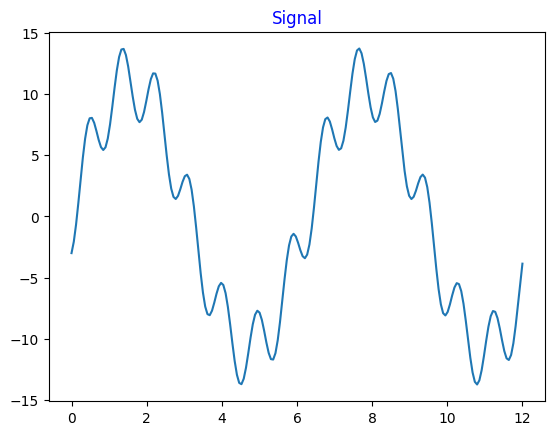

In [14]:
n = 200

# Definerer n punkter i intervallet [0, 9]
x = np.linspace(0.0, 12.0, n)

# Definerer n punkter i y ud fra x
y = 11 * np.sin(x) - 3*np.cos(7*x)

# Tegner figuren
fig, ax = plt.subplots()
ax.set_title("Signal", color="b")
ax.plot(x,y)

## b) Definer en ny y-array der er påvirket af støj

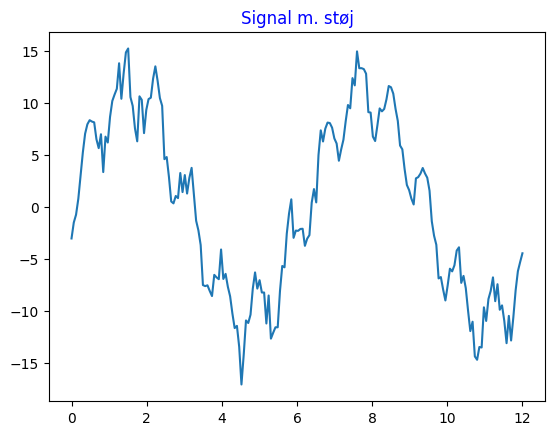

In [15]:
# Definerer ny y-array med støj:
rng = np.random.default_rng()
støj = rng.standard_normal(n)

ystøj = y + støj

# Tegner figuren
fig, ax = plt.subplots()
ax.set_title("Signal m. støj", color="b")
ax.plot(x,ystøj)

## c) Definering af matricen A

In [16]:
# Definerer en 0 matrice af den ønskede størrelse
A = np.zeros((n,n))

# et loop der indsætter 1/3 på 3 diagonaler
for i in (-1, 0 ,1):
    A += np.diag(np.ones(n-abs(i))*1/3, i)
    
A

array([[0.33333333, 0.33333333, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.33333333, 0.33333333, 0.33333333, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.33333333, 0.33333333, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.33333333, 0.33333333,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.33333333, 0.33333333,
        0.33333333],
       [0.        , 0.        , 0.        , ..., 0.        , 0.33333333,
        0.33333333]])

## d) Plot 𝐴𝑦støj. Det burde ses at den har en form, som er tættere på 𝑦 end på 𝑦støj. Forklar hvorfor.

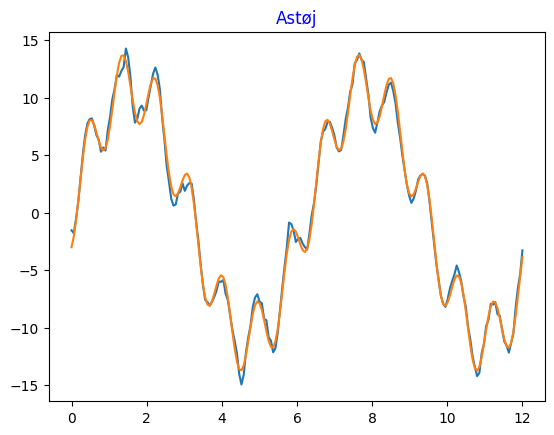

In [24]:
# Beregning af AYstøj
AYstøj = A @ ystøj

# Tegner figuren
fig, ax = plt.subplots()
ax.set_title("Astøj", color="b")
ax.plot(x,AYstøj)
ax.plot(x, y)

Grunden til at denne graf ser "glattere" ud end den med støj, er fordi hvert punkt egentlig er et gennemsnit af sig selv, og dets omkring liggende punkter.

## e) Angivelse af en matrice B som resulterer i en mere støjfri BYstøj

Det som matricen A gør, er at tage gennemsnittet af en værdi y, og tager gennemsnittet af den og dens to nabo punkter, og lader dette gennemsnit være det nye punkt.

Jeg kan nu bestemme en ny matrice B, som beregner et gennemsnit på en måde der bedre ved at vægte hvor vigtige de omkringliggende punkters værdier er.

In [18]:
# Definerer en 0 matrice af den ønskede størrelse
B = np.zeros((n,n))

# et loop der indsætter 1/5 på 5 diagonaler
# Her der der skaleret til 1/5 fordi vi har 5 diagonaler, ellers bliver dataen skaleret så vi måske får et maksimum på 15 fremfor 10.

#Forsøg 1
#for i in (-2, -1, 0, 1, 2):
    #B += np.diag(np.ones(n-abs(i))*1/5, i)

#Forsøg 2
B += np.diag(np.ones(n-1)*1/5, -1)
B += np.diag(np.ones(n)*3/5, 0)
B += np.diag(np.ones(n-1)*1/5, 1)

#Forsøg 3

    
B

array([[0.6, 0.2, 0. , ..., 0. , 0. , 0. ],
       [0.2, 0.6, 0.2, ..., 0. , 0. , 0. ],
       [0. , 0.2, 0.6, ..., 0. , 0. , 0. ],
       ...,
       [0. , 0. , 0. , ..., 0.6, 0.2, 0. ],
       [0. , 0. , 0. , ..., 0.2, 0.6, 0.2],
       [0. , 0. , 0. , ..., 0. , 0.2, 0.6]])

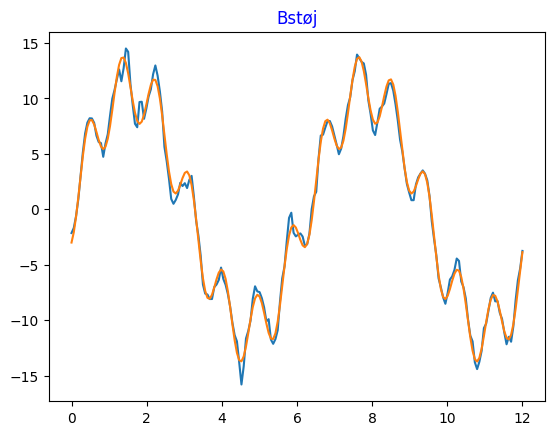

In [25]:
# Beregning af AYstøj
BYstøj = B @ ystøj

# Tegner figuren
fig, ax = plt.subplots()
ax.set_title("Bstøj", color="b")
ax.plot(x,BYstøj)
ax.plot(x, y)

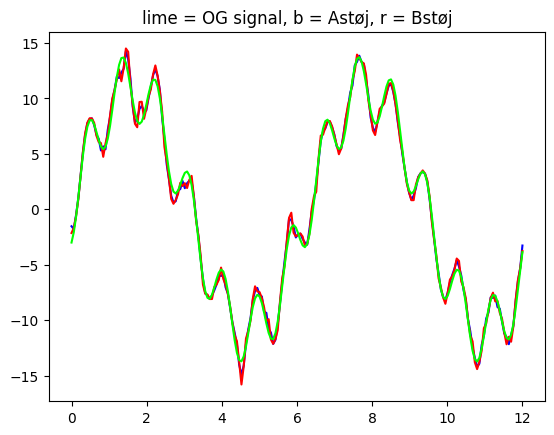

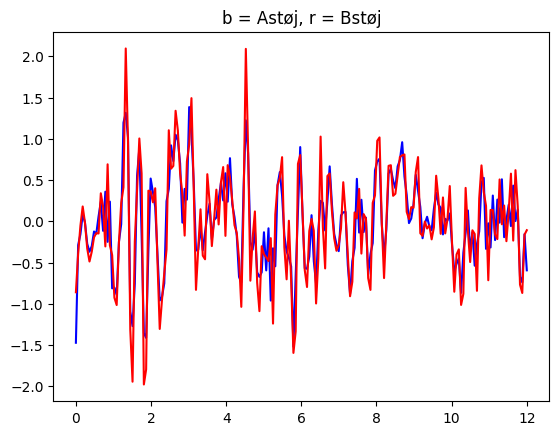

In [20]:
# Absolut fejl
AYafejl = (y-AYstøj)

BYafejl = (y-BYstøj)

# Relativ fejl (%)
AYrfejl = (y-AYstøj)/AYstøj*100

BYrfejl = (y-BYstøj)/BYstøj*100


# Tegner de to reducerede grafer og den oprindelige graf
fig, cx = plt.subplots()
cx.set_title("lime = OG signal, b = Astøj, r = Bstøj")
cx.plot(x,AYstøj, color="b")
cx.plot(x,BYstøj, color="r")
cx.plot(x,y, color="lime")

# Tegner Absolut fejl
fig, bx = plt.subplots()
bx.set_title("b = Astøj, r = Bstøj")
bx.plot(x,AYafejl, color="b")
bx.plot(x,BYafejl, color="r")


In [21]:
# Jeg kan nu bestemme normen af en den absolutte fejl vektor af begge støjreduktioner. 
# Den bedste af disse reduktioner vil være den med den mindste norm, da det vil være denne der er tættest på det originale signal.

print("norm(AYafejl) = " + str(np.linalg.norm(AYafejl)))
print("norm(BYafejl) = " + str(np.linalg.norm(BYafejl)))



norm(AYafejl) = 7.595153639151297
norm(BYafejl) = 9.098483412976657


Jeg kan nu konkludere at man med min støjreduktionsmatrice B, vil få en bedre støjreduktion end med A, i tilfældet hvor n = 100.
Hvis man derimod sætter n = 1000, så vil man få at A er bedre. Dette er fordi punkterne lægger meget tættere, så her ville det være en bedre ide at tage et vægtet gennemnsnit, med mere vægt på de omkring liggende punkter.

bøj_A(bøj_C(S))

bøj_C(bøj_A(S))

$bøj_A(S) = \begin{bmatrix} a | R_Ab | R_Ac | R_A D \end{bmatrix}$

$R_A R_C = R_C R_A$